In [2]:

from google.colab import files
uploaded = files.upload()

Saving Price_Agriculture_commodities_Week.csv to Price_Agriculture_commodities_Week (1).csv


In [3]:
import pandas as pd

data = pd.read_csv("Price_Agriculture_commodities_Week.csv")
data.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0


In [4]:
# Convert date
data['Arrival_Date'] = pd.to_datetime(data['Arrival_Date'])
data['Year'] = data['Arrival_Date'].dt.year
data['Month'] = data['Arrival_Date'].dt.month
data = data.drop('Arrival_Date', axis=1)

# Remove missing values
data = data.dropna()

# Convert categorical
data = pd.get_dummies(data)

/tmp/ipykernel_560/3302511056.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Arrival_Date'] = pd.to_datetime(data['Arrival_Date'])


In [5]:
X = data.drop('Modal Price', axis=1)
y = data['Modal Price']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(loss='mse', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train, y_train, epochs=20)

Epoch 1/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2087288.5000
Epoch 2/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 207233.2812
Epoch 3/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 216463.8594
Epoch 4/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 228494.6562
Epoch 5/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 228491.3906
Epoch 6/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 206565.0938
Epoch 7/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 226842.1406
Epoch 8/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 222024.3281
Epoch 9/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 266599.6250
Epoch 10/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 203057.7656
Epoch 11/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 219001.0781
Epoch 12/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 199440.1562
Epoch 13/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 205779.2500
Epoch 14/20
578/578 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss

In [9]:
pred = model.predict(X_test)

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 650625.705555187
R2 Score: 0.9817889015234665


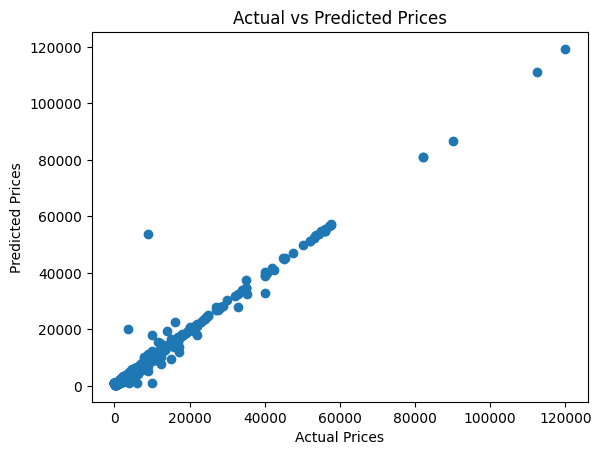

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()